<a href="https://colab.research.google.com/github/sruthi-analyst/sruthi-codeboosters-2026/blob/main/Day9/Day_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##AI Agent is an LLM that can:

- Use tools
- Take multiple steps
- Decide which action to take
- Act on the real world (does not need a human to perform the steps)
- Can access live data (not just trained data)
Can query database

AGENT: RAG
ChatBot: FAQ Bot

Chat bot - only returns a generated content explaining the process or topic that we asked.

##MUlti-step Reasoning: The ReAct Pattern
1. Think - understand user's intent
2. Plan - prepares pre requisutes and steps
3. Act - performs that steps
4. Respond - return the response

##Major methods in Agentic AI
1. get_*curr_structure_of_data-schema* ()
2. generate_*step-sql* () by calling LLM
3. execute_*steps-sql* () and returns results in a DataFrame

#AGENTIC AI PREREQUISITES

In [4]:
!pip install groq -q

print("Libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.5 MB/s eta 0:00:00
Libraries installed successfully!


In [5]:
#Libraries required
import sqlite3          #dataase communication
import os               #store api key in environ vars safely
import pandas as pd     #work on the data set easily using a dataframe
from groq import Groq   #to access LLM models
import re               #to get required format

print("All libraries imported successfully")

All libraries imported successfully


In [6]:
import os
from google.colab import userdata

# Retrieve the secret securely
try:
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
    print("API Key successfully loaded from Colab Secrets!")
except userdata.SecretNotFoundError:
    print("Error: Please add 'GROQ_API_KEY' to your Colab Secrets sidebar.")

API Key successfully loaded from Colab Secrets!


In [7]:
client = Groq(api_key=os.environ["GROQ_API_KEY"])
print("Groq client initialized successfully!")

#insert model
MODEL = "llama-3.1-8b-instant"

print("groq client initialised")
print(f"Using model: {MODEL}")

Groq client initialized successfully!
groq client initialised
Using model: llama-3.1-8b-instant


In [8]:
import io  #io = input output
csv_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/student_performance.csv")
print("Imported Dataset into DataFrame successfully!")

print("First 5 rows of the dataset")
print(csv_data.head())
print("\n Shape of dataset: ", csv_data.shape)
print("\n", csv_data.describe())

Imported Dataset into DataFrame successfully!
First 5 rows of the dataset
   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai       

In [9]:
conn = sqlite3.connect("study_statistics.db")
csv_data.to_sql("students", conn, if_exists="replace", index=False)
print("SQLite database loaded with Dataset successfully!")

#test db connection
test_df = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM students", conn)
print(f"\nVerification {test_df['total_rows'][0]} rows in database")

SQLite database loaded with Dataset successfully!

Verification 30 rows in database


#AGENITC AI
## GET  ~*~   GENERATE  ~*~   EXECUTE

In [10]:
def get_schema(conn, table_name="students"):
  """
  Reads structure of database...
  PARAMS:
    conn : DB connection through ehich we are accessing the table
    table_name : name of table we need to access now
  ...
  """

  #Query SQLite's internal table info
  cursor = conn.cursor()  #connection to SQLite used to execute SQL query

  cursor.execute(f"PRAGMA table_info({table_name})")  #PRAGMA table_info is built-in python function to show all columns names of the table
  #PRAGMA table_info - a special SQLite command that return columns names
  columns = cursor.fetchall()
  #returns a list of tuples, one tuple per column
  #Example tuple : (0, 'student_id', 'INTEGER', 0, None, ...)

  #build a human-readable schema description
  schema_lines = [f"Table: {table_name}"]
  schema_lines.append("Columns: ")

  for col in columns:
    #col[1]: column name(second element of the tuple)
    #col[2]: data type(third element)
    schema_lines.append(f"  - {col[1]} ({col[2]})")

  #Add sample values to  help AI understand the data
  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
  sample_data = cursor.fetchall()
  schema_lines.append("\nSample rows (first 3): ")

  for row in sample_data:
    schema_lines.append(f"  {row}")

  return "\n".join(schema_lines)
  #"\n".join : Joins all lines with a new line
schema = get_schema(conn)
print(schema)

Table: students
Columns: 
  - student_id (INTEGER)
  - name (TEXT)
  - age (INTEGER)
  - gender (TEXT)
  - department (TEXT)
  - semester (INTEGER)
  - math_score (INTEGER)
  - science_score (INTEGER)
  - english_score (INTEGER)
  - programming_score (INTEGER)
  - attendance_percentage (INTEGER)
  - city (TEXT)
  - admission_year (INTEGER)

Sample rows (first 3): 
  (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
  (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
  (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [11]:
def generate_sql(user_question, schema_text, client, model):
  """
  Sends the user's questions and database schema to the Groq model.
  Groq LLM Generates a SQL query that answers the user's question.
  PARAMS:
    user_question: Qn typed by the user
    schema_text: ..
  RETURNS:
    A single string containing the generated SQL query.
  """

  #Define the system prompt = instruction we give
  system_prompt = f"""You are the developer of SQL.
  You are connected to a SQLite database with the following structure:
  {schema_text}

  Rules you must follow:
  1. Generate ONLY a valid SQLite SQL query.
  2. Do not include any explanation or text — only the SQL query.
  3. Do not use markdown code blocks. Return the raw SQL only.
  4. The table name is: students
  5. Only use column names that exist in the schema above.
  6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
  7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
  """

  #call groq api
  response = client.chat.completions.create(
      model=model,
      messages=[
          {"role": "system", "content": system_prompt},
          {"role": "user", "content": user_question}
      ],
      temperature = 0.0
  )

  sql_query = response.choices[0].message.content.strip()
  return sql_query


In [12]:
question = "Show me all female students"
print(f"Question: {question}")
print("\nGenerating SQL...")

sql_gender = generate_sql(question, schema, client, MODEL)
print(f"\nGenerated SQL:\n{sql_gender}")


Question: Show me all female students

Generating SQL...

Generated SQL:
SELECT * FROM students WHERE gender = 'Female'


In [13]:
question = "List all students scored >90 in maths and programming"
print(f"Question: {question}")
print("\nGenerating SQL...")

sql_topper = generate_sql(question, schema, client, MODEL)
print(f"\nGenerated SQL:\n{sql_topper}")

Question: List all students scored >90 in maths and programming

Generating SQL...

Generated SQL:
SELECT * FROM students WHERE math_score > 90 AND programming_score > 90


In [14]:
question = "Create a new table with examination scores alone and add a column named total_score"
print(f"Question: {question}")
print("\nGenerating SQL...")

sql_new_table = generate_sql(question, schema, client, MODEL)
print(f"\nGenerated SQL:\n{sql_new_table}")

Question: Create a new table with examination scores alone and add a column named total_score

Generating SQL...

Generated SQL:
CREATE TABLE examination_scores AS
SELECT name, math_score, science_score, english_score, programming_score,
       math_score + science_score + english_score + programming_score AS total_score
FROM students;


In [15]:
def execute_sql(sql_query, conn):
  """ this is an sql query executing function """
  clean_sql = sql_query.strip()
  clean_sql = re.sub(r'```\s*','', clean_sql)
  clean_sql = sql_query.strip()

  try:
    result_df = pd.read_sql_query(clean_sql, conn)
    return result_df, None
  except Exception as e:
    return None, str(e)

In [16]:
print(f"Execute SQL: {sql_gender}")
result_gender, error_gender = execute_sql(sql_gender, conn)

if error_gender:
  print(f"Error: {error_gender}")
else:
  print(f"Query returned {len(result_gender)} rows:")
  print(result_gender)

print()
print("= ="*20)
print()
print(f"Execute SQL: {sql_topper}")
result_topper, error_topper = execute_sql(sql_topper, conn)

if error_topper:
  print(f"Error: {error_topper}")
else:
  print(f"Query returned {len(result_topper)} rows:")
  print(result_topper)

print()
print("= ="*20)
print()
print(f"Execute SQL: {sql_new_table}")
result_new_table, error_new_table = execute_sql(sql_new_table, conn)

if error_new_table:
  print(f"Error: {error_new_table}")
else:
  print(f"Query returned {len(result_new_table)} rows:")
  print(result_new_table)

Execute SQL: SELECT * FROM students WHERE gender = 'Female'
Query returned 15 rows:
    student_id            name  age  gender        department  semester  \
0         1002     Priya Patel   20  Female  Computer Science         2   
1         1004     Sneha Reddy   20  Female        Mechanical         2   
2         1006     Meera Joshi   20  Female       Electronics         2   
3         1008     Divya Singh   19  Female  Computer Science         2   
4         1010      Ananya Das   19  Female  Computer Science         2   
5         1012     Pooja Gupta   19  Female             Civil         2   
6         1014   Kavya Nambiar   20  Female        Mechanical         2   
7         1016    Ritu Agarwal   20  Female       Electronics         2   
8         1018  Swati Kulkarni   19  Female  Computer Science         2   
9         1020    Nisha Kapoor   19  Female  Computer Science         2   
10        1022     Tanvi Mehta   19  Female  Computer Science         2   
11        1024  

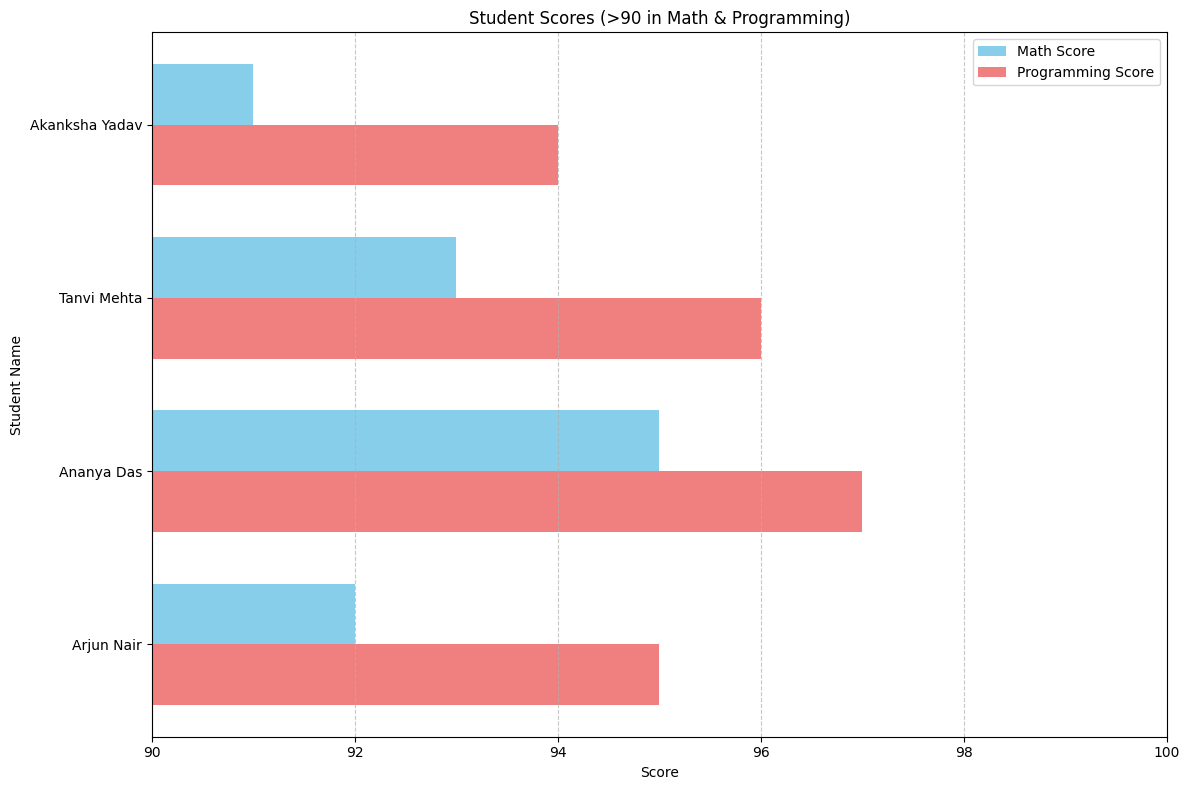

In [18]:
import matplotlib.pyplot as plt

df_plot = result_topper[['name', 'math_score', 'programming_score']]

student_names = df_plot['name'].tolist()
math_scores = df_plot['math_score'].tolist()
programming_scores = df_plot['programming_score'].tolist()
num_students = len(student_names)

bar_height = 0.35
ind = range(num_students)
plt.figure(figsize=(12, 8))
plt.barh([i + bar_height/2 for i in ind], math_scores, height=bar_height, label='Math Score', color='skyblue')
plt.barh([i - bar_height/2 for i in ind], programming_scores, height=bar_height, label='Programming Score', color='lightcoral')

plt.xlabel('Score')
plt.ylabel('Student Name')
plt.title('Student Scores (>90 in Math & Programming)')
plt.yticks(ind, student_names)
plt.xlim(90, 100)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
## the complete Text-to-SQL Agent Function

def def_to_sql_agent(user_question,conn,client,model,verbose=True):
  """ this is main AI function """
  print(f"User question:{user_question}")
  print("="*60)

  #step 1 = verbose get the db schema
  if verbose:
    print("\n[STEP 1] Reading database schema")
  schema_text=get_schema(conn)

  if verbose:
    print("Schema loaded succssfully")

  ##step -2 generate SQL

  if verbose:
    print("\n[STEP 2] Generating SQL query with groq LLM...")

  generated_sql=generate_sql(user_question,schema_text,client,model)


  if verbose:
    print(f'Generated SQL:\n{generated_sql}')


  #STEP 3:EXECUTE SQL ON THE DB

  if verbose:
    print("\n [STEP 3] Executing SQL on db...")

  # Fix: Pass generated_sql string, not the function itself
  result_df,error = execute_sql(generated_sql,conn)


  if error:
    print(f'Error executing SQL:{error}')
    return None,generated_sql

##STEP 4 display the results

  if verbose:
    print(f'\n STEP 4 QUERY RETURNED{len(result_df)} row(s)')
    print("\nRESULTS:")
    print("-"*60)
    print(result_df.to_string(index=False))

  print("="*60)
  return result_df,generated_sql


#test our complete agent

result,sql_used = def_to_sql_agent(
    "Show top 5 students with Programming",
    conn,client,MODEL
)

User question:Show top 5 students with Programming

[STEP 1] Reading database schema
Schema loaded succssfully

[STEP 2] Generating SQL query with groq LLM...
Generated SQL:
SELECT name, programming_score FROM students ORDER BY programming_score DESC LIMIT 5

 [STEP 3] Executing SQL on db...

 STEP 4 QUERY RETURNED5 row(s)

RESULTS:
------------------------------------------------------------
          name  programming_score
    Ananya Das                 97
   Tanvi Mehta                 96
    Arjun Nair                 95
Akanksha Yadav                 94
   Divya Singh                 93
